In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#load the dataset
df = pd.read_csv('car_sales_data (2).csv.crdownload',encoding='utf-8')

In [ ]:
#understand the dataset
#starting few rows
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [11]:
#last few rows
df.tail()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630
49999,VW,Golf,1.4,Diesel,2012,109300,10400


In [12]:
#summerize the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [13]:
#summerize the dataset of numeric columns
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [14]:
#data cleaning
#df.drop('column_name', axis=1, inplace=True)  # Example of dropping a column
#df.insert(2, 'New_Column', value)  # Example of inserting a new column
#df.loc[row_index, 'Column_Name'] = new_value  # Example of updating a value
#df.rename(columns={'Old_Name': 'New_Name'}, inplace=True)  # Example of renaming a column
#df.replace(to_replace, value, inplace=True)  # Example of replacing values

In [15]:
#handling missing values
df.isnull().sum()  # Check for missing values

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [ ]:
#df.dropna(axis=0/1,inplace=True)  # drop columns/rows with missing values
#df.fillna(value,inplace=True)  # fill missing values with a specified value
#df['Column_Name'].fillna(df['Column_Name'].mean(), inplace=True)  # fill missing values with the mean of the column

In [16]:
#accessing specific columns
df['Price']  # Access a single column
df[['Price', 'Mileage']]  # Access multiple columns

,Price,Mileage
0,3074,127300
1,49704,57850
2,24072,39190
3,1705,210814
4,4101,127869
...,...,...
49995,113006,28664
49996,9430,105120
49997,49852,4030
49998,23630,26468


In [17]:
df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


In [20]:
#sort the data
df.sort_values(by='Price', ascending=True,inplace=True)

In [23]:
df.reset_index(drop=True, inplace=True)
df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,VW,Polo,1.0,Petrol,1987,422895,76
1,Ford,Fiesta,1.2,Petrol,1984,396901,85
2,Ford,Fiesta,1.4,Petrol,1984,395085,94
3,Ford,Fiesta,1.0,Petrol,1985,375388,103
4,Ford,Fiesta,1.2,Petrol,1986,391920,103
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2022,9797,163608
49996,Porsche,911,3.5,Petrol,2022,6963,164343
49997,Porsche,911,3.5,Petrol,2022,2931,167774
49998,BMW,M5,5.0,Petrol,2022,4683,168001


In [27]:
#rename columns
df.rename(columns={'Manufacturer':'Car_Manufacturer'},inplace=True)

In [28]:
#average price of cars  
average_price = df['Price'].mean()
print(f"The average price of cars is: ${average_price:.2f}")

The average price of cars is: $13828.90


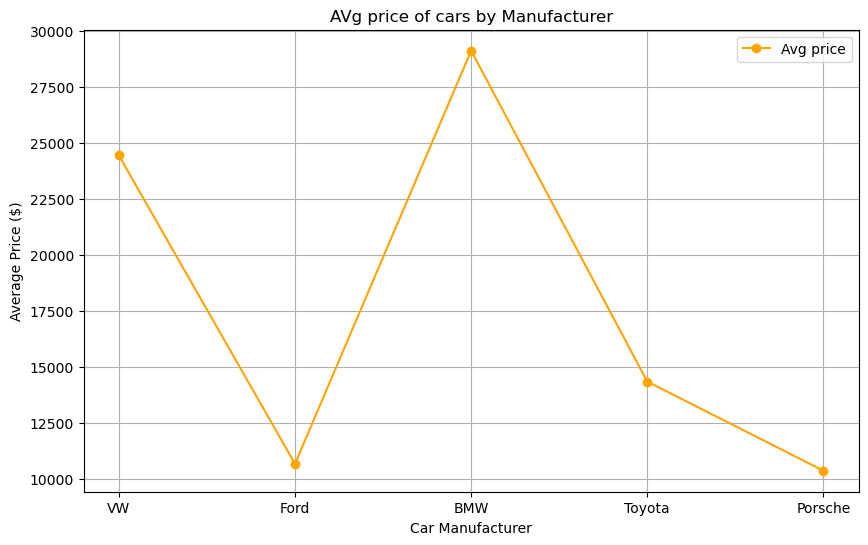

In [32]:
#line plot
#AVERAGE PRICE OF CARS 
average_price = df.groupby('Car_Manufacturer')['Price'].mean()
plt.figure(figsize=(10, 6))
plt.plot(df['Car_Manufacturer'].unique(), average_price, marker='o',color='orange',label='Avg price')
plt.title('AVg price of cars by Manufacturer')
plt.xlabel('Car Manufacturer')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True)  
plt.show()

In [46]:
#group by
average_price = df.groupby('Car_Manufacturer')['Price'].mean().reset_index()




In [48]:
#average mileage of cars
average_mileage = df['Mileage'].mean()  
print(f"The average mileage of cars is: {average_mileage:.2f} miles")

The average mileage of cars is: 112497.32 miles


In [53]:
#avg engine size and mileage by manufacturer
avg_engine_mileage = df.groupby('Car_Manufacturer').agg({'Engine size': 'mean', 'Mileage': 'mean'}).reset_index()
avg_engine_mileage.rename(columns={'Engine size': 'Avg_Engine_size', 'Mileage': 'Avg_Mileage'}, inplace=True)
print(avg_engine_mileage)

  Car_Manufacturer  Avg_Engine_size    Avg_Mileage
0              BMW         3.102437  112837.733333
1             Ford         1.485968  112525.884819
2          Porsche         2.966079  111638.253737
3           Toyota         1.574367  111361.126494
4               VW         1.576987  113462.092939


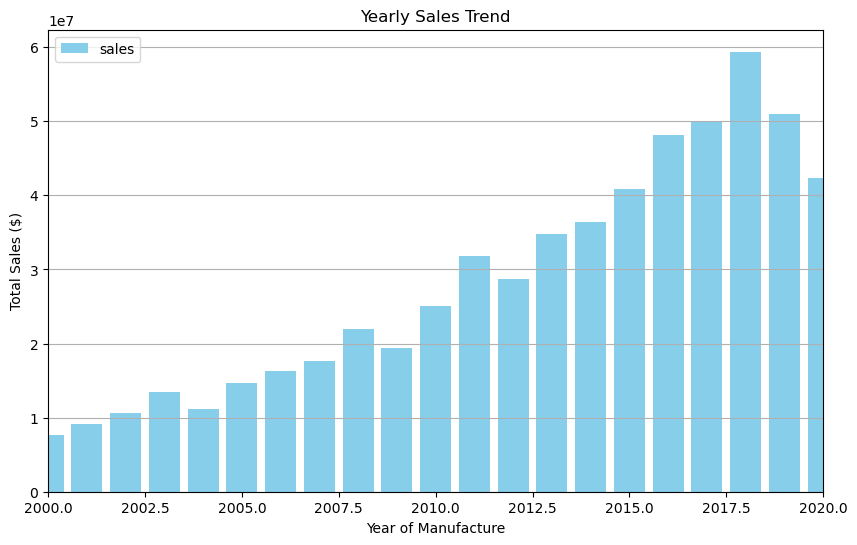

In [59]:
#yearly sales trend
yearly_sales = df.groupby('Year of manufacture')['Price'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(df['Year of manufacture'].unique(), yearly_sales['Price'], color='skyblue',label='sales')
plt.title('Yearly Sales Trend')
plt.xlabel('Year of Manufacture')   
plt.ylabel('Total Sales ($)')
plt.xlim(2000, 2020)
plt.legend()
plt.grid(axis='y')
plt.show()

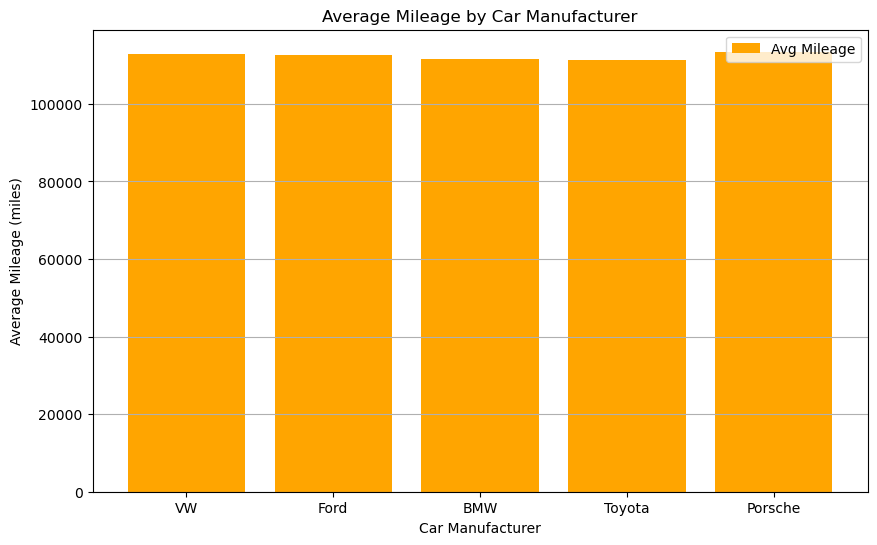

In [94]:
#avg milage vs car manufacturer
avg_mileage = df.groupby('Car_Manufacturer')['Mileage'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(df['Car_Manufacturer'].unique(), avg_mileage['Mileage'], color='orange',label='Avg Mileage')
plt.title('Average Mileage by Car Manufacturer')
plt.xlabel('Car Manufacturer')
plt.ylabel('Average Mileage (miles)')
plt.legend()
plt.grid(axis='y')  
plt.show()

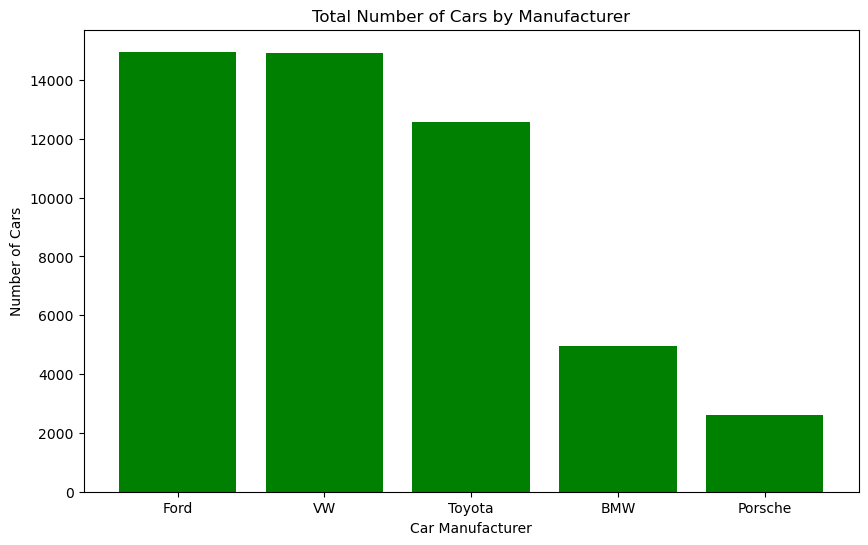

In [66]:
#total number car by manufacturer
#histogram
manufacturer_counts = df['Car_Manufacturer'].value_counts()
plt.figure(figsize=(10, 6)) 
plt.bar(manufacturer_counts.index, manufacturer_counts.values, color='green')
plt.title('Total Number of Cars by Manufacturer')
plt.xlabel('Car Manufacturer')
plt.ylabel('Number of Cars')
plt.show()


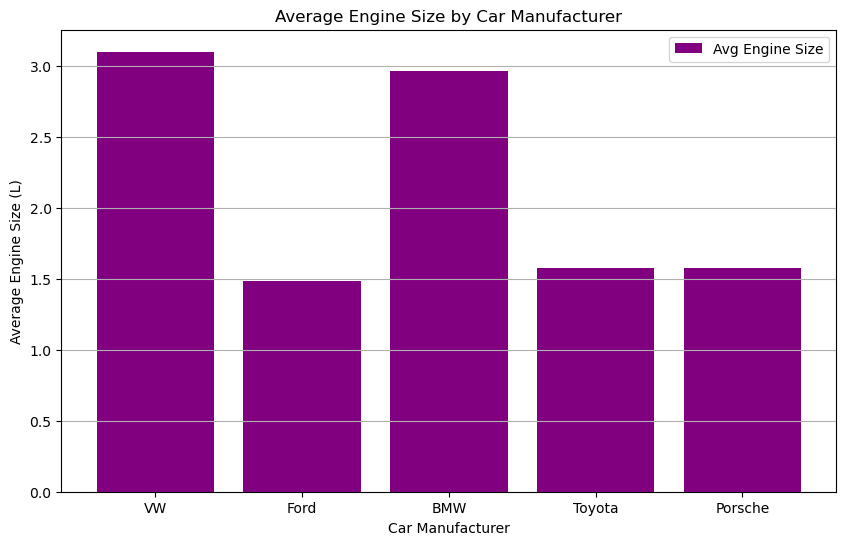

In [67]:
#engine size vs car manufacturer
engine_size = df.groupby('Car_Manufacturer')['Engine size'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(df['Car_Manufacturer'].unique(), engine_size['Engine size'], color='purple',label='Avg Engine Size')
plt.title('Average Engine Size by Car Manufacturer')
plt.xlabel('Car Manufacturer')
plt.ylabel('Average Engine Size (L)')
plt.legend()
plt.grid(axis='y')
plt.show()

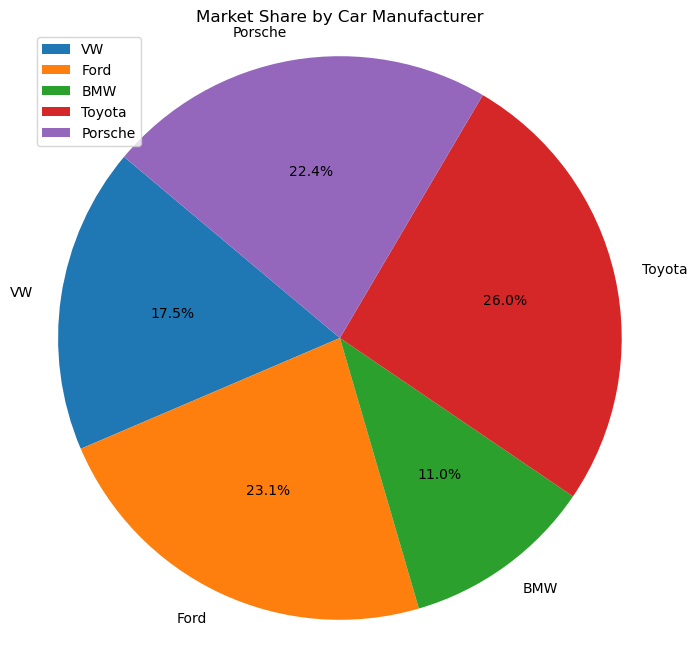

In [70]:
#pie chart of car manufacturers
cost =df.groupby('Car_Manufacturer')['Price'].sum()
plt.figure(figsize=(8, 8))
plt.pie(cost, labels=df['Car_Manufacturer'].unique(), autopct='%1.1f%%', startangle=140)
plt.title('Market Share by Car Manufacturer')
plt.legend()
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [82]:
#avgerage mileage by manufacturer
average_mileage = df.groupby('Car_Manufacturer')['Mileage'].mean()

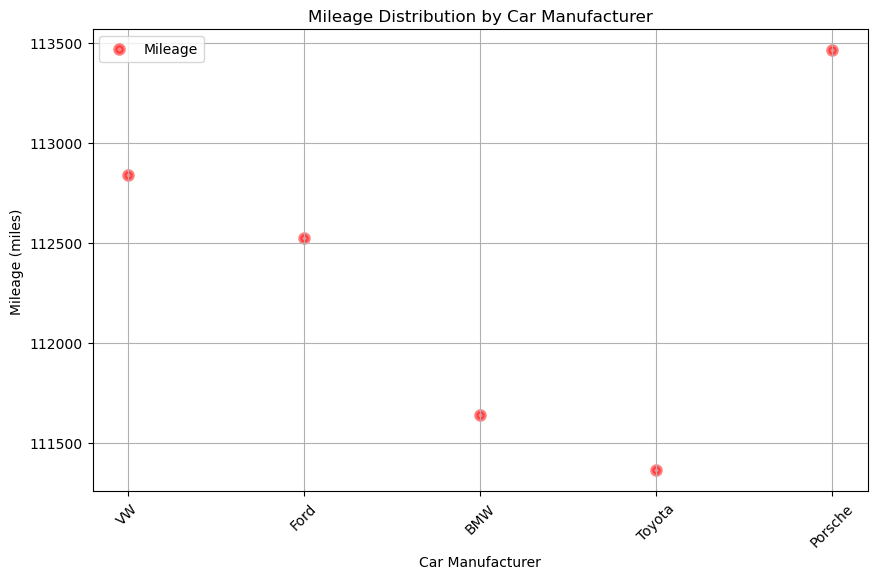

In [84]:
#avg milage of cars
#scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Car_Manufacturer'].unique(), average_mileage, color='red',linewidths=3,marker='o' ,alpha=0.5,label='Mileage')
plt.title('Mileage Distribution by Car Manufacturer')
plt.xlabel('Car Manufacturer')
plt.ylabel('Mileage (miles)')
plt.xticks(rotation=45) 
plt.legend()
plt.grid(True)
plt.show()

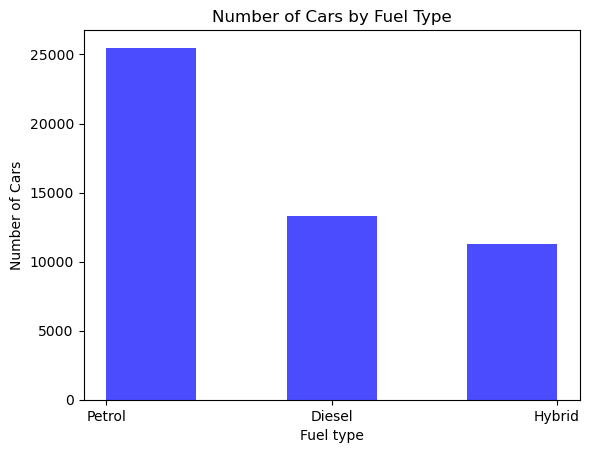

<Figure size 800x600 with 0 Axes>

In [92]:
#histogaram
#no of car vs fuel type
plt.hist(df['Fuel type'], bins=5, color='blue', alpha=0.7)
plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel type')
plt.ylabel('Number of Cars')
plt.figure(figsize=(8, 6))
plt.show()



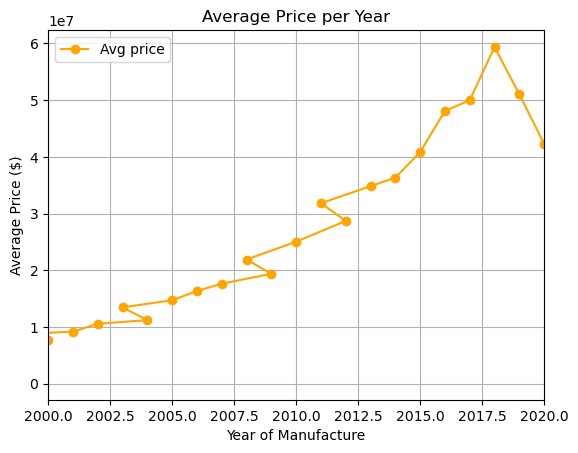

In [95]:
#avg price per year
#line
# --- IGNORE ---
plt.plot(df['Year of manufacture'].unique(), yearly_sales['Price'], marker='o',color='orange',label='Avg price')
plt.title('Average Price per Year')
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Price ($)')
plt.xlim(2000, 2020)
plt.legend()
plt.grid()